In [1]:
import numpy
import matplotlib.pyplot as plt
import scipy
import pandas
import seaborn

print("All imports OK")
print(numpy.__file__)
print(plt.__file__)

All imports OK
/home/govind/gov_semproject/GridCellsTheta/GridCellsCond/.venv/lib/python3.13/site-packages/numpy/__init__.py
/home/govind/gov_semproject/GridCellsTheta/GridCellsCond/.venv/lib/python3.13/site-packages/matplotlib/pyplot.py


In [2]:
from neuron import h
h.load_file('stdrun.hoc')
import numpy as np
import matplotlib.pyplot as plt
import stellate
import interneuron_amb
import importlib
importlib.reload(stellate)
h.celsius = 37.0
h.steps_per_ms = 40
h.dt = 0.025
h.cvode_active(0)

0.0

In [3]:
stellate_0 = stellate.Stellate(0)
interneuron_0 = interneuron_amb.Interneuron(0)

In [363]:
stell_ic_0 = h.IClamp(stellate_0.soma(0.5))
stell_ic_0.dur = 1e9

sim_dur = 10000 #in ms
num_steps = int(sim_dur/h.dt)
time_arr = np.arange(0,sim_dur,h.dt)

stell_v = h.Vector().record(stellate_0.soma(0.5)._ref_v)
stellate_gh_vec = h.Vector().record(stellate_0.soma(0.5).stellate_mech._ref_gh)
stellate_gnap_vec = h.Vector().record(stellate_0.soma(0.5).stellate_mech._ref_gna)
nc_stell = h.NetCon(stellate_0.soma(0.5)._ref_v, None, sec=stellate_0.soma)
nc_stell.threshold = 0
spike_times_stell = h.Vector()
nc_stell.record(spike_times_stell)
time = h.Vector().record(h._ref_t)



In [376]:
syn_inh = h.ExpSyn(stellate_0.soma(0.5))
syn_inh.e = -80
syn_inh.tau = 10.0


n_points = len(time_arr)

stell_ic = h.IClamp(stellate_0.soma(0.5))
stell_ic.dur = 1e9
dc_val = -2.7e-4
inhib_dc = np.full(n_points,dc_val,dtype=np.float64)
stell_dc_vec = h.Vector(inhib_dc)
stell_dc_vec.play(stell_ic._ref_amp,h.dt)

Vector[215]

In [428]:
g_max = 0.001
g_min = 0.00005
tau_fall = 800.0
tau_rise = 400.0

theta_freq = 8.0
mod_depth = 0.08
init_phase = np.random.uniform(0,2*np.pi)
print(init_phase)

idx_1 = int(2000/h.dt)
idx_2 = int(6500/h.dt)
idx_3 = int(6500/h.dt)

inhib_base = np.full(n_points,g_max)
t_phase1 = time_arr[idx_1:idx_2] - time_arr[idx_1]
inhib_base[idx_1:idx_2] = (g_max-g_min)*(np.exp(-t_phase1/tau_fall)) + g_min

inhib_base[idx_2:idx_3] = inhib_base[idx_2-1]

t_phase3 = time_arr[idx_3:] - time_arr[idx_3]
start_val = inhib_base[idx_3 - 1]
inhib_base[idx_3:] = start_val + (g_max-start_val)*(1-np.exp(-t_phase3/tau_rise))
#inhib_base[idx_3:] = start_val*np.exp(t_phase3/tau_rise)
theta_factor = 1 + (mod_depth*(np.sin(2*np.pi*theta_freq*time_arr/1000.0)))
inhib_cond_arr = inhib_base #* theta_factor
noise = np.random.normal(loc=0.0,scale=1e-5,size=len(inhib_cond_arr))
inhib_cond_arr += noise
inhib_cond_arr = np.maximum(inhib_cond_arr,0.00001)

g_vec = h.Vector(inhib_cond_arr)
g_vec.play(syn_inh._ref_g, h.dt)
g_rec = h.Vector().record(syn_inh._ref_g)



6.201861413909717


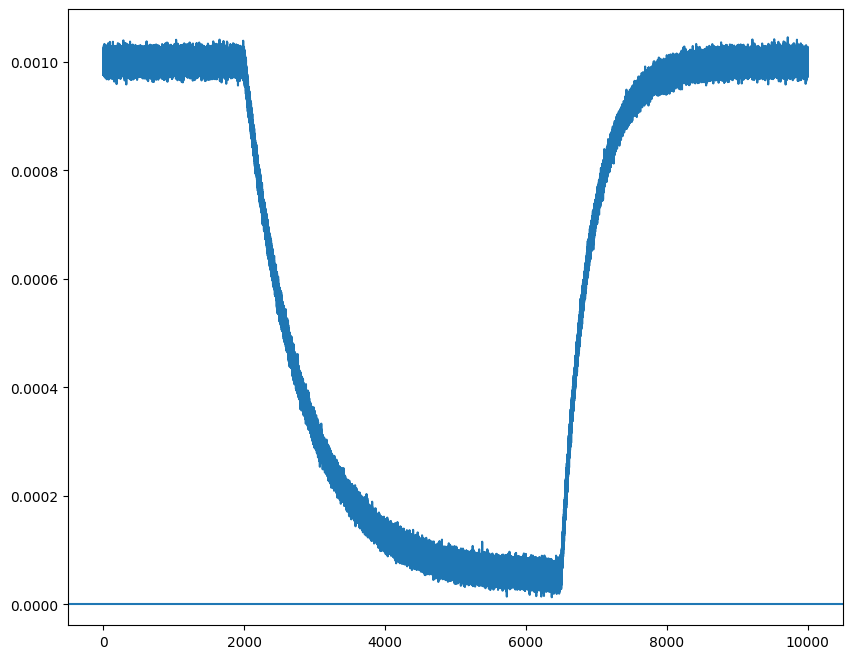

In [429]:
plt.figure(figsize=(10,8))
plt.plot(time_arr,inhib_cond_arr)
plt.axhline(y=0.0)
#plt.xlim(3800,4500)

In [430]:
h.finitialize(-80)
h.frecord_init()
h.continuerun(sim_dur)

0.0

In [431]:
#phase extraction

spikes_arr = np.array(spike_times_stell.to_python())
phases = ((init_phase+((spikes_arr) * theta_freq * 2 * np.pi / 1000)) % (2 * np.pi))
phases_shifted = phases + 2*np.pi

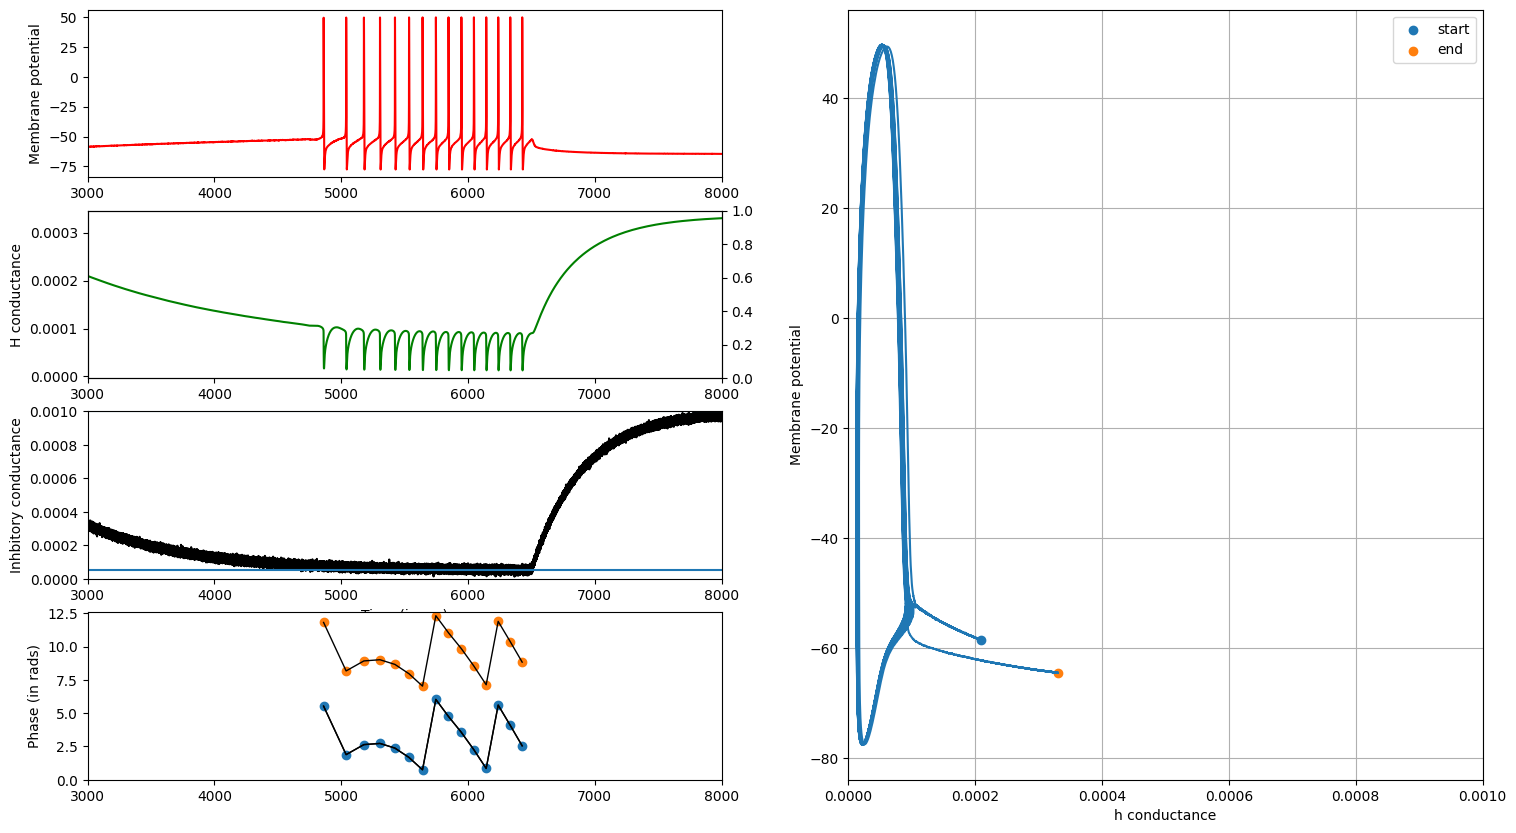

In [433]:
from matplotlib.gridspec import GridSpec

gh_cond = stellate_gh_vec.to_python()
gnap_cond = stellate_gnap_vec.to_python()
memb_pot = stell_v.to_python()
start_time = 3000
end_time =  8000
start_idx = int(start_time/h.dt)
end_idx = int(end_time/h.dt)

fig = plt.figure(figsize=(18,10))

gs = GridSpec(4,2,width_ratios=[1,1])
ax0 = fig.add_subplot(gs[0,0])
ax1 = fig.add_subplot(gs[1,0])
ax1_1 = ax1.twinx()
ax2 = fig.add_subplot(gs[2,0])
ax3 = fig.add_subplot(gs[3,0])

ax_phase = fig.add_subplot(gs[:,1])


ax1.plot(time_arr[start_idx:end_idx],gh_cond[start_idx:end_idx],color='green')
ax2.set_xlabel("Time (in ms)")
ax2.set_ylabel("Inhbitory conductance")
ax1.set_ylabel("H conductance")
#ax1_1.plot(time_arr[start_idx:end_idx],gnap_cond[start_idx:end_idx],color='purple')
ax0.set_ylabel("Membrane potential")
ax0.plot(time_arr[start_idx:end_idx],memb_pot[start_idx:end_idx],color='red')
ax2.plot(time_arr[start_idx:end_idx],inhib_cond_arr[start_idx:end_idx],color='black')
ax2.axhline(y=g_max)
ax3.plot(spikes_arr,phases,linewidth=1,color='black')
ax2.axhline(y=g_min)
ax3.plot(spikes_arr,phases,linewidth=1,color='black')
ax3.plot(spikes_arr,phases_shifted,linewidth=1,color='black')
ax3.scatter(spikes_arr,phases)
ax3.scatter(spikes_arr,phases_shifted)
ax3.set_ylabel("Phase (in rads)")
ax3.set_ylim(0,4*np.pi)
ax_phase.plot(gh_cond[start_idx:end_idx],memb_pot[start_idx:end_idx])
ax_phase.scatter(gh_cond[start_idx],memb_pot[start_idx],label='start')
ax_phase.scatter(gh_cond[end_idx],memb_pot[end_idx],label='end')
ax_phase.legend()
ax_phase.set_xlabel("h conductance")
ax_phase.set_ylabel("Membrane potential")
ax_phase.set_xlim(0,0.001)
ax0.set_xlim(start_time,end_time)
ax1.set_xlim(start_time,end_time)
ax2.set_xlim(start_time,end_time)
ax3.set_xlim(start_time,end_time)
ax2.set_ylim(0,0.001)
plt.grid(True)
plt.show()





In [517]:
print(phases)

[1.06785199 5.95617016 4.68319682 4.89305521 4.60277204 4.35144463
 4.30117915 4.26599331 4.23457738 4.31500216 4.29489596 4.29363933
 4.31248888 4.27855968 4.29363933 4.25594021 4.28358623 4.28986941
 4.33259507 4.29489596 4.30997561]
